In [24]:
!pip install pytorch-lightning


In [25]:
import os
import json
import shutil
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from torchvision.ops import box_iou
from pathlib import Path
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO
import tempfile
from torchvision.models.detection import FasterRCNN

In [26]:
!pip install pycocotools


In [27]:
json_path = "annotations.json"
output_root = ""

# Criação de pastas
splits = ['train', 'val', 'test']
for split in splits:
    os.makedirs(os.path.join(output_root, "images", split), exist_ok=True)

# Carregar ficheiro JSON
with open(json_path, 'r') as f:
    data = json.load(f)

# Criar índice por id para acesso rápido
id_to_image = {img['id']: img for img in data['images']}

annotations = data['annotations']['pieces']

# Criação de índice de anotações por imagem_id
annotations_by_image = {}
for ann in annotations:
    image_id = ann['image_id']
    if ann.get('bbox'):
        bbox = ann['bbox']
    else:
        continue
    annotations_by_image.setdefault(image_id, []).append(bbox)

# Estrutura base do COCO
coco_base = {
    "info": {
        "year": "2025",
        "version": "1",
        "description": "Chess Pieces Detect",
        "contributor": "CM,GB,DM,MB",
        "url": "",
        "date_created": "2025-06-11T14:30:00+00:00"
    },
    "licenses": [
        {
            "id": 1,
            "url": "https://creativecommons.org/publicdomain/zero/1.0/",
            "name": "Public Domain"
        }
    ],
    "categories": [
        {"id": 1, "name": "Chess Piece", "supercategory": "none"},
    ]
}

# Processar splits
for split in splits:
    coco_output = coco_base.copy()
    coco_output["images"] = []
    coco_output["annotations"] = []
    annotation_id = 0

    ids = data['splits']['chessred2k'].get(split, [])
    for image_id in ids['image_ids']:
        image_info = id_to_image.get(image_id)
        if not image_info:
            print(f"[AVISO] ID {image_id} não encontrado em 'images'")
            continue

        src_path = "chessred2k/" + image_info.get('path')
        if not src_path or not os.path.isfile(src_path):
            print(f"[AVISO] Ficheiro não encontrado: {src_path}")
            continue

        dst_path = os.path.join(output_root, "images", split, image_info['file_name'])
        shutil.copy2(src_path, dst_path)

        coco_output["images"].append({
            "id": image_id,
            "license": 1,
            "file_name": image_info['file_name'],
            "height": image_info['height'],
            "width": image_info['width'],
        })

        for ann in annotations_by_image.get(image_id, []):
            x, y, w, h = ann
            coco_output["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": 1,
                "bbox": [x, y, w, h],
                "area": w * h,
                "segmentation": [],
                "iscrowd": 0
            })
            annotation_id += 1

    # Guardar ficheiro JSON por split
    ann_dir = os.path.join(output_root, "images", split)
    os.makedirs(ann_dir, exist_ok=True)
    with open(os.path.join(ann_dir, f"annotations.json"), 'w') as out_json:
        json.dump(coco_output, out_json, indent=4)

In [28]:
# Define transformations
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        return image, target

In [29]:


# --------------- Dataset ----------------
class DummyChessDataset:
    def __init__(self, root="images/"):
        self.image_paths = list(Path(root).glob("*.jpg"))
        self.boxes = [torch.tensor([[50, 60, 120, 160]], dtype=torch.float32) for _ in self.image_paths]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img_tensor = F.to_tensor(img)
        return img_tensor, self.boxes[idx]

# --------------- Metrics ----------------
def evaluate_map(pred_boxes, pred_scores, gt_boxes, iou_thresh=0.5):
    TP, FP, FN = 0, 0, 0
    for preds, scores, targets in zip(pred_boxes, pred_scores, gt_boxes):
        preds = preds[scores > 0.5]
        matched = []
        for t in targets:
            best_iou = 0
            for i, p in enumerate(preds):
                if i in matched: continue
                iou = box_iou(p.unsqueeze(0), t.unsqueeze(0)).item()
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
            if best_iou >= iou_thresh:
                TP += 1
                matched.append(best_idx)
            else:
                FN += 1
        FP += len(preds) - len(matched)
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    return precision, recall, TP, FP, FN

# --------------- Inference ----------------
def run_frcnn_eval():
    model = fasterrcnn_resnet50_fpn(pretrained=True).eval()
    dataset = DummyChessDataset()

    preds_all, scores_all, targets_all = [], [], []

    for i in range(len(dataset)):
        img, gt_box = dataset[i]
        with torch.no_grad():
            output = model([img])[0]
        boxes = output['boxes'].cpu()
        scores = output['scores'].cpu()

        preds_all.append(boxes)
        scores_all.append(scores)
        targets_all.append(gt_box)

    p, r, TP, FP, FN = evaluate_map(preds_all, scores_all, targets_all)
    print(f"Faster R-CNN → P: {p:.3f}, R: {r:.3f}, TP: {TP}, FP: {FP}, FN: {FN}")



In [30]:
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Load datasets
train_dataset = get_coco_dataset(
    img_dir="images/train",
    ann_file="images/train/annotations.json"
)


val_dataset = get_coco_dataset(
    img_dir="images/val",
    ann_file="images/val/annotations.json"
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.25s)
creating index...
index created!


In [31]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [32]:
num_classes = 2
model = get_model(num_classes)

c:\Users\Caty\Documents\ComputerVision\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Caty\Documents\ComputerVision\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [33]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [34]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, writer=None):
    model.train()
    total_loss = 0.0
    count = 0  # batches com targets válidos

    for step, (images, targets) in enumerate(data_loader):
        # Move images para o dispositivo
        images = [img.to(device) for img in images]

        # Processar os targets
        processed_targets = []
        valid_images = []

        for i, target in enumerate(targets):
            boxes = []
            labels = []
            for obj in target:
                bbox = obj.get("bbox", [])
                if len(bbox) != 4:
                    continue
                x, y, w, h = bbox
                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])
                    labels.append(obj["category_id"])

            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device),
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])

        if not processed_targets:
            continue

        images = valid_images

        # Forward + backward
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Logging
        total_loss += losses.item()
        count += 1

        if writer:
            for k, v in loss_dict.items():
                writer.add_scalar(f"Loss/{k}", v.item(), epoch * len(data_loader) + step)
            writer.add_scalar("Loss/total", losses.item(), epoch * len(data_loader) + step)

    avg_loss = total_loss / count if count > 0 else 0.0
    print(f"[Epoch {epoch}] Média da loss: {avg_loss:.4f}")

    # Logging por época
    if writer:
        writer.add_scalar("EpochLoss/total", avg_loss, epoch)

In [35]:
# Training loop
writer = SummaryWriter("runs/fasterrcnn_exp")

num_epochs = 50
start_epoch = 0

for epoch in range(start_epoch, num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch, writer)
    lr_scheduler.step()

    # Save full checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': lr_scheduler.state_dict()
    }
    torch.save(checkpoint, 'fasterrcnn/checkpoint.pth')
    print(f"Checkpoint saved at epoch {epoch + 1}")

writer.close()


[Epoch 0] Média da loss: 0.2349
Checkpoint saved at epoch 1
[Epoch 1] Média da loss: 0.1320
Checkpoint saved at epoch 2


KeyboardInterrupt: 

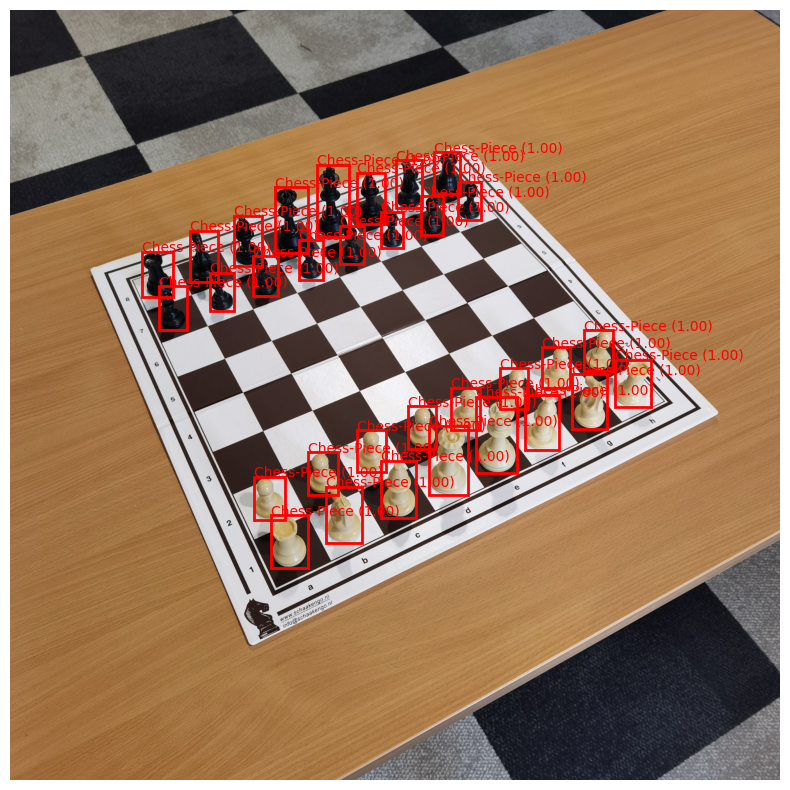

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# Initialize the model
num_classes = 2  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# Load the trained model
model = get_model(num_classes)
checkpoint = torch.load('fasterrcnn/checkpoint.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
#model.load_state_dict(torch.load("fasterrcnn/checkpoint.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode


def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Open image
    image_tensor = F.to_tensor(image).unsqueeze(0)  # Convert image to tensor and add batch dimension
    return image_tensor.to(device)



# Load the unseen image
image_path = "images/test/G000_IMG000.jpg"
image_tensor = prepare_image(image_path)

with torch.no_grad():  # Disable gradient computation for inference
    prediction = model(image_tensor)

# `prediction` contains:
# - boxes: predicted bounding boxes
# - labels: predicted class labels
# - scores: predicted scores for each box (confidence level)
COCO_CLASSES = {0: "Background", 1: "Chess-Piece", 2: "Person", 3: "Table"}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")
    
# Draw bounding boxes with the correct class names and increase image size
def draw_boxes(image, prediction, fig_size=(10, 10)):
    boxes = prediction[0]['boxes'].cpu().numpy()  # Get predicted bounding boxes
    labels = prediction[0]['labels'].cpu().numpy()  # Get predicted labels
    scores = prediction[0]['scores'].cpu().numpy()  # Get predicted scores
    
    # Set a threshold for showing boxes (e.g., score > 0.5)
    threshold = 0.5
    
    # Set up the figure size to control the image size
    plt.figure(figsize=fig_size)  # Adjust the figure size here

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)  # Get the class name
            plt.imshow(image)  # Display the image
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                              linewidth=2, edgecolor='r', facecolor='none'))
            plt.text(x_min, y_min, f"{class_name} ({score:.2f})", color='r')
    
    plt.axis('off')  # Turn off axis
    plt.show()

# Display the image with bounding boxes and correct labels
draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))  # Example of increased size

## Transfer Learning with Faster R-CNN: Freeze Backbone and Train Head Only

In [ ]:
def get_model2(num_classes):
    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

    # Congelar todos os parâmetros do backbone
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Substituir a cabeça de deteção
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [ ]:
num_classes = 2
model = get_model2(num_classes)

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
# Training loop
writer = SummaryWriter("runs/fasterrcnn_exp2")

num_epochs = 50
start_epoch = 0

for epoch in range(start_epoch, num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch, writer)
    lr_scheduler.step()

    # Save full checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': lr_scheduler.state_dict()
    }
    torch.save(checkpoint, f'fasterrcnn_freeze/checkpoint{epoch}.pth')
    print(f"Checkpoint saved at epoch {epoch + 1}")

writer.close()


[Epoch 0] Média da loss: 0.2617
Checkpoint saved at epoch 1
[Epoch 1] Média da loss: 0.2303
Checkpoint saved at epoch 2
[Epoch 2] Média da loss: 0.2048
Checkpoint saved at epoch 3
[Epoch 3] Média da loss: 0.2019
Checkpoint saved at epoch 4
[Epoch 4] Média da loss: 0.1994
Checkpoint saved at epoch 5
[Epoch 5] Média da loss: 0.1963
Checkpoint saved at epoch 6
[Epoch 6] Média da loss: 0.1969
Checkpoint saved at epoch 7
[Epoch 7] Média da loss: 0.1968
Checkpoint saved at epoch 8
[Epoch 8] Média da loss: 0.1970
Checkpoint saved at epoch 9
[Epoch 9] Média da loss: 0.1962
Checkpoint saved at epoch 10
[Epoch 10] Média da loss: 0.1959
Checkpoint saved at epoch 11
[Epoch 11] Média da loss: 0.1966
Checkpoint saved at epoch 12
[Epoch 12] Média da loss: 0.1964
Checkpoint saved at epoch 13
[Epoch 13] Média da loss: 0.1961
Checkpoint saved at epoch 14
[Epoch 14] Média da loss: 0.1961
Checkpoint saved at epoch 15
[Epoch 15] Média da loss: 0.1967
Checkpoint saved at epoch 16
[Epoch 16] Média da loss: 0

In [17]:
# Define o modelo com o mesmo número de classes
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Carregar o modelo e o checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=2)  # 1 classe + background
checkpoint = torch.load('fasterrcnn_freeze/checkpoint10.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
model.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Caty/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 63.4MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [ ]:
# Initialize the model
num_classes = 2  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# Load the trained model
model = get_model(num_classes)
checkpoint = torch.load('fasterrcnn/checkpoint.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
#model.load_state_dict(torch.load("fasterrcnn/checkpoint.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode


def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Open image
    image_tensor = F.to_tensor(image).unsqueeze(0)  # Convert image to tensor and add batch dimension
    return image_tensor.to(device)



# Load the unseen image
image_path = "images/test/G000_IMG000.jpg"
image_tensor = prepare_image(image_path)

with torch.no_grad():  # Disable gradient computation for inference
    prediction = model(image_tensor)

# `prediction` contains:
# - boxes: predicted bounding boxes
# - labels: predicted class labels
# - scores: predicted scores for each box (confidence level)
COCO_CLASSES = {0: "Background", 1: "Chess-Piece", 2: "Person", 3: "Table"}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")
    
# Draw bounding boxes with the correct class names and increase image size
def draw_boxes(image, prediction, fig_size=(10, 10)):
    boxes = prediction[0]['boxes'].cpu().numpy()  # Get predicted bounding boxes
    labels = prediction[0]['labels'].cpu().numpy()  # Get predicted labels
    scores = prediction[0]['scores'].cpu().numpy()  # Get predicted scores
    
    # Set a threshold for showing boxes (e.g., score > 0.5)
    threshold = 0.5
    
    # Set up the figure size to control the image size
    plt.figure(figsize=fig_size)  # Adjust the figure size here

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)  # Get the class name
            plt.imshow(image)  # Display the image
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                              linewidth=2, edgecolor='r', facecolor='none'))
            plt.text(x_min, y_min, f"{class_name} ({score:.2f})", color='r')
    
    plt.axis('off')  # Turn off axis
    plt.show()

# Display the image with bounding boxes and correct labels
draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))  # Example of increased size

### Test Model Freeze

In [18]:
class CustomCocoDetection(CocoDetection):
    def __init__(self, root, annFile):
        super().__init__(root, annFile, transforms=CocoTransform())

# Exemplo
test_dataset = CustomCocoDetection("images/test", "images/test/annotations.json")
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [ ]:
model.eval()
outputs_buffer = []

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for img_idx, output in enumerate(outputs):
            if isinstance(targets[img_idx], list) and len(targets[img_idx]) > 0:
                image_id = targets[img_idx][0].get("image_id", img_idx)
            else:
                image_id = img_idx
            boxes = output["boxes"].cpu().tolist()
            scores = output["scores"].cpu().tolist()
            labels = output["labels"].cpu().tolist()

            for box, score, label in zip(boxes, scores, labels):
                x_min, y_min, x_max, y_max = box
                outputs_buffer.append({
                    "image_id": image_id,
                    "category_id": label,
                    "bbox": [x_min, y_min, x_max - x_min, y_max - y_min],
                    "score": score
                })

# Guardar as previsões temporariamente
with tempfile.NamedTemporaryFile(mode='w+', delete=False, suffix='.json') as f:
    json.dump(outputs_buffer, f)
    pred_file = f.name

# Avaliação com COCO
coco_gt = COCO("images/test/annotations.json")
coco_dt = coco_gt.loadRes(pred_file)
coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# Extração das métricas
stats = coco_eval.stats
print("\n🔍 Métricas detalhadas:")
print(f"mAP@[0.5:0.95]:      {stats[0]:.4f}")
print(f"mAP@0.5:             {stats[1]:.4f}")
print(f"mAP@0.75:            {stats[2]:.4f}")
print(f"Recall@1:           {stats[6]:.4f}")
print(f"Recall@10:          {stats[7]:.4f}")
print(f"Recall@100:         {stats[8]:.4f}")
print(f"Precision média:     {stats[0]:.4f}")


loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.06s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.23s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.788
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.990
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.966
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.788
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.042
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.407
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet